<a href="https://colab.research.google.com/github/FattahulAlim/MFattahul-PCVK_ganjil_2026/blob/main/p2_15_MuhammadFattahulAlim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identitas Diri
1. Nama : Muhammad Fattahul Alim
2. NIM : 244107020018
3. Kelas : TI-3G
4. Absen : 15

In [ ]:
#Membuat koneksi antara google collab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Mengakses gambar
from google.colab import files
uploaded = files.upload()

Saving KTM_cahaya_matahari.jpg to KTM_cahaya_matahari.jpg


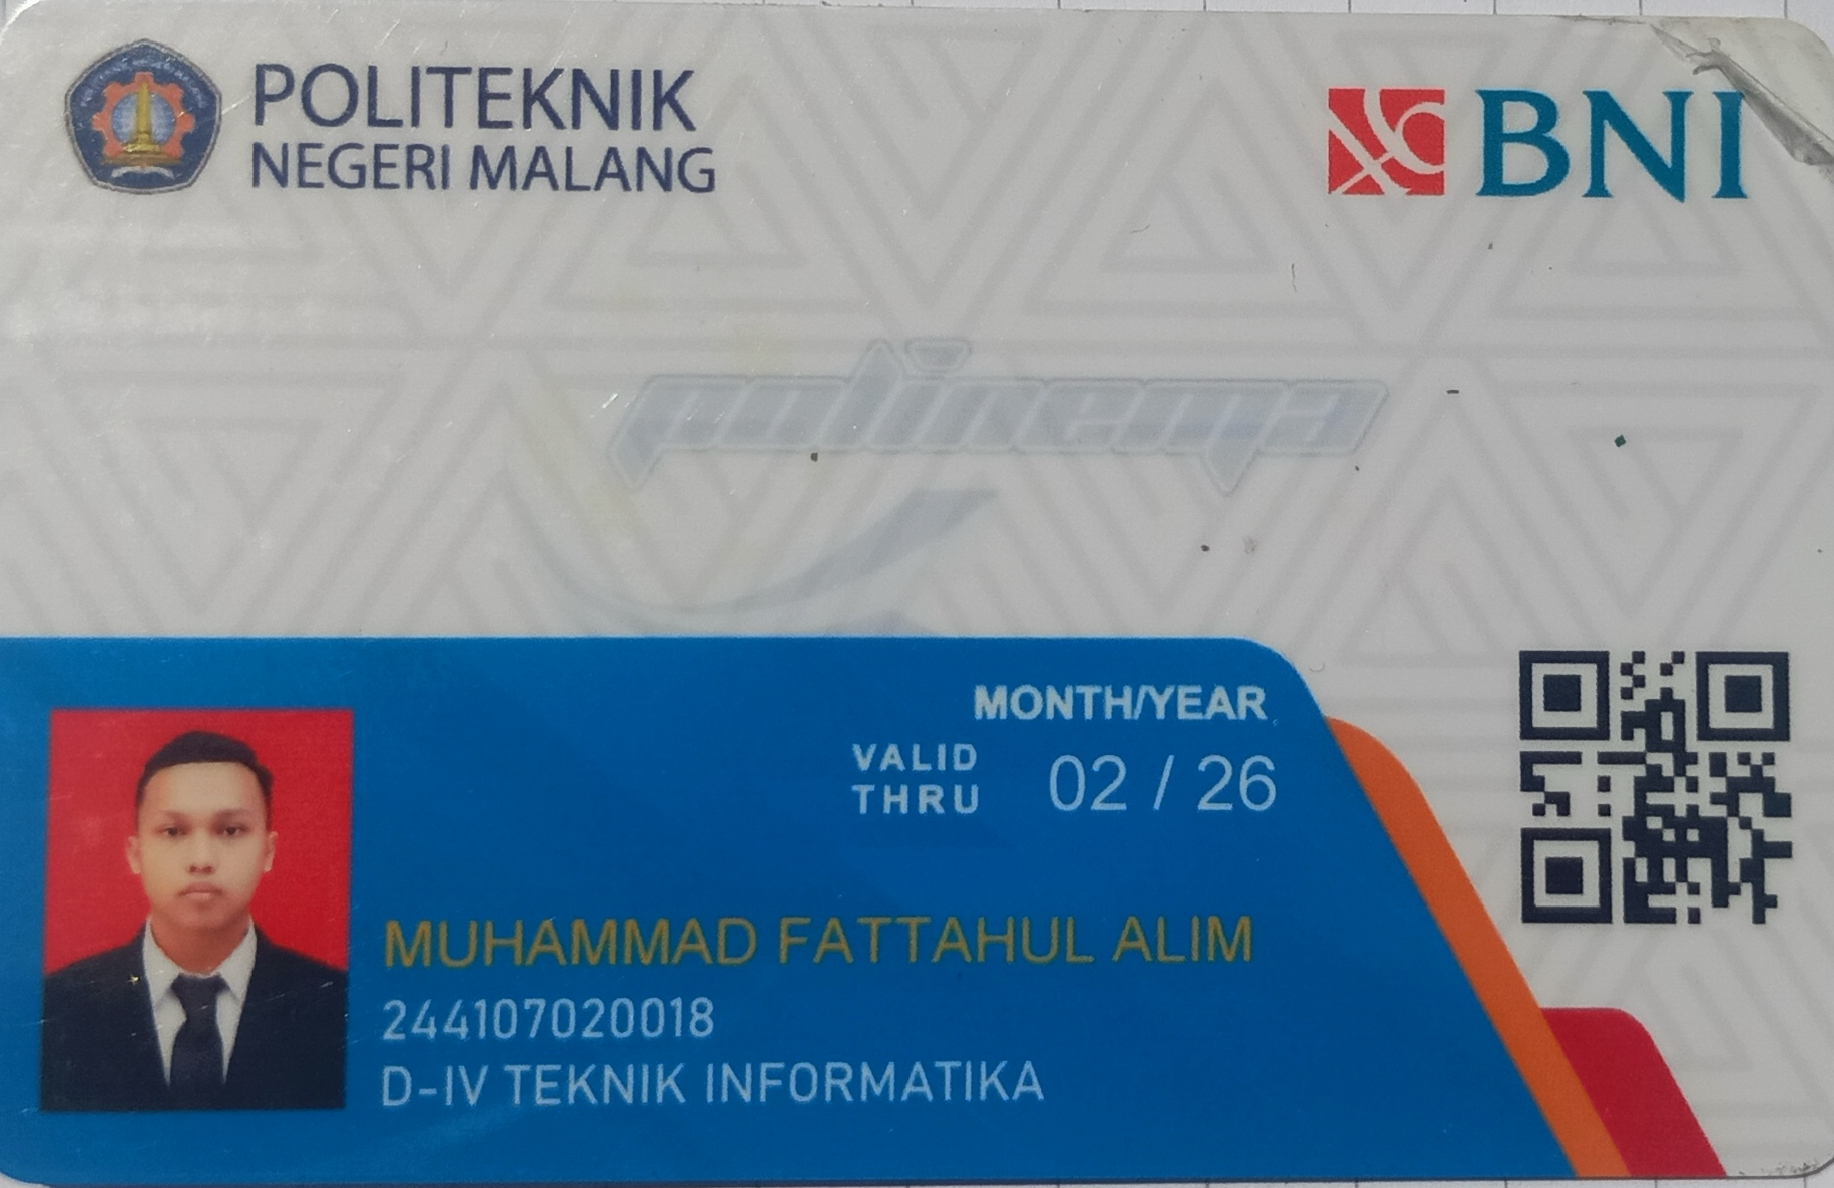

Resolusi gambar:  1834  x  1188


In [ ]:
#Menampilkan gambar
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTM_cahaya_matahari.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

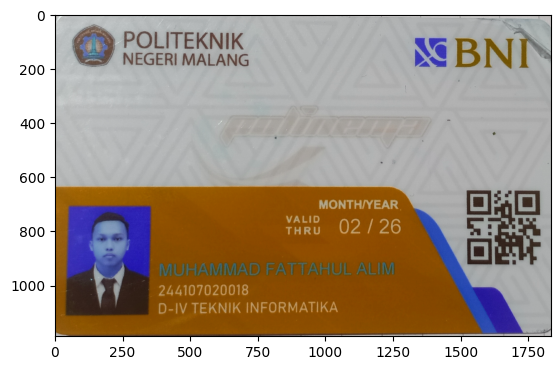

In [ ]:
#Menampilkan gambar dengan matplotlib
img = cv.imread('KTM_cahaya_matahari.jpg')
plt.imshow(img) # Format warna BGR

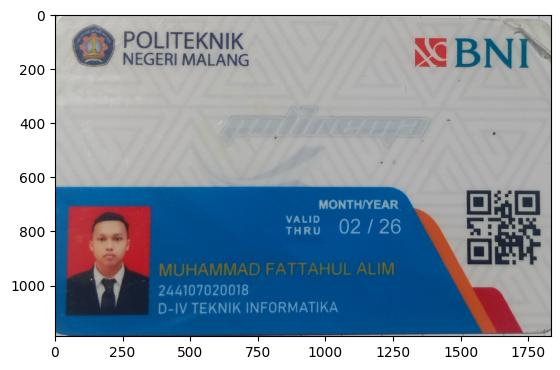

In [ ]:
img = cv.imread('KTM_cahaya_matahari.jpg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) # Format warna BGR -> RGB
plt.imshow(img2)

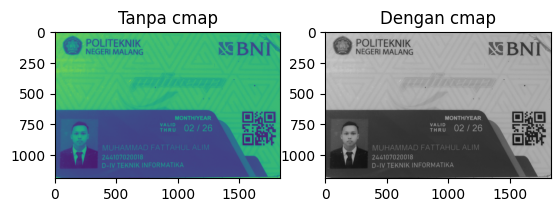

In [ ]:
#Menampilkan citra gray scale
img_gray = cv.imread('KTM_cahaya_matahari.jpg', cv.IMREAD_GRAYSCALE)

#Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

#Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

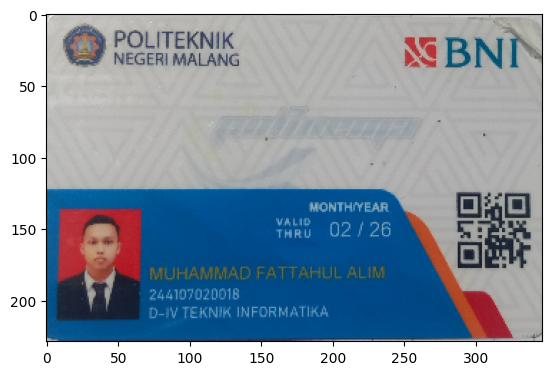

In [ ]:
#Melakukan resizing
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB) #Konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347, 229))
plt.imshow(img_output)

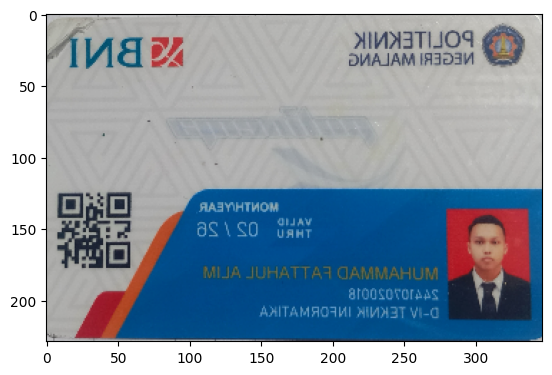

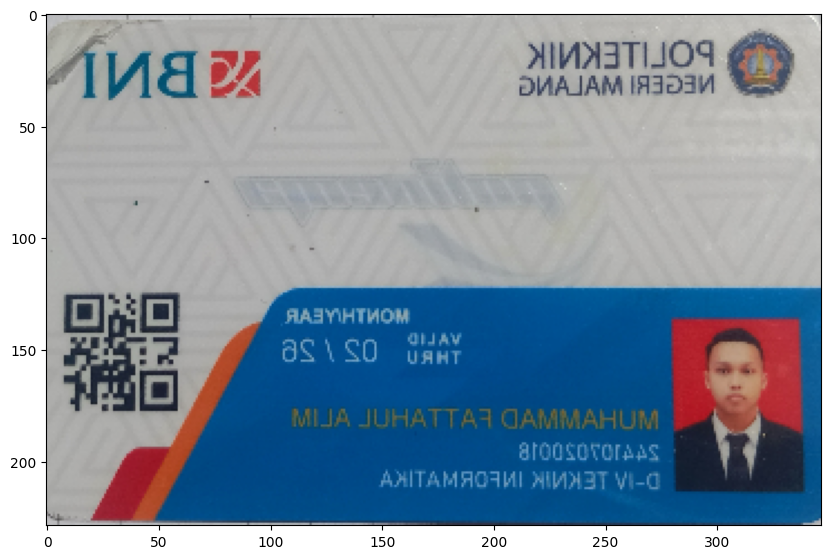

In [ ]:
#Melakukan Flipping
imgFlip = cv.flip(img_output, 1)
plt.imshow(imgFlip)

#Resize canvas menjadi lebih besar
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

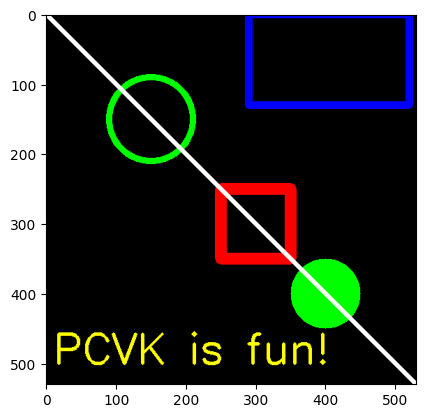

In [ ]:
#Membuat geometri 2D
black_img = np.zeros(shape=(530,530,3), dtype=np.int16)
plt.imshow(black_img)

cv.rectangle(black_img, pt1=(290, 0), pt2=(520,130), color=(0,0,255), thickness=10)
cv.rectangle(black_img, pt1=(250, 250), pt2=(350,350), color=(255,0,0), thickness=15)
cv.circle(black_img, center=(150, 150), radius=60, color=(0,255,0), thickness=8)
cv.circle(black_img, center=(400, 400), radius=50, color=(0,255,0), thickness=-1)
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255,255,255), thickness=5)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10, 500), fontFace=font, fontScale=2, color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)


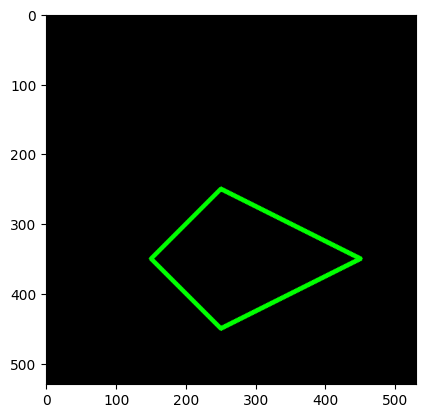

In [ ]:
#Membuat black image lagi dengan tipe data int32
black_img2 = np.zeros(shape=(530,530,3), dtype=np.int32)

vertices = np.array([[150,350], [250,250], [450,350], [250,450]], dtype=np.int32)
pts = vertices.reshape((-1,1,2)) #Nilai 2 untuk menunjukkan bahwa tiap titik dibuat dari 3 channel yang mewakili RGB
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

# Jawaban Pertanyaan Praktikum

1. Secara visual warna pada gambar yang ditampilkan berbeda. tampilan dengan cv2_imshow() menunjukkan warna yang normal sementara plt.imshow() menunjukkan warna yang agak berbeda atau tidak sesuai dengan aslinya padahal nilai pixel pada koordinat yang sama bernilai sama yaitu  [180 185 186]. Hal ini terjadi karena tetapi karena perbedaan urutan kanal warna dalam membaca dan menampilkan citra. Library OpenCV memakai urutan kanal warna BGR (blue, green, red) sementara library matplotlib menggunakan kanal warna RGB (red, green, blue) akibatnya kanal merah dan birut menjadi tertukar, ini penyebab utama terdapat perbedaan visual pada warna citra.
2.  Pada tampilan serta nilai min dan max warna pada pixel kanvas hitam tidak berbeda sama sekali. Hal ini disebabkan oleh fungsi np.zeros() yang menyebabkan seluruh elemen array (warna) diisi dengan angka 0 sehingga tampilannya sama serta hasil dari .min() dan .max() juga bernilai sama yaitu 0. Berbeda halnya dengan ukuran memorinya, kanvas hitam dengan tipe data int32 memiliki memori yang lebih besar dibandingkan tipe data int16 karena tipe data int16 hanya menggunakan 16 bit untuk menyimpan satu angka sementara int32 menggunakan 32 bit
3. Baris from google.colab.patches import cv2_imshow digunakan untuk mengimpor fungsi khusus buatan Google yang berfungsi sebagai fungsi pengganti dari cv2.imshow agar gambar dari OpenCV dapat ditampilkan langsung di dalam sel output Google Colab. cv2.imshow() sendiri tidak bisa dijalankan di google collab karena fungsi itu dirancang untuk berjalan dan berinteraksi dengan tampilan di sistem operasi, contohnya saat fungsi tersebut dijalankan maka akan memunculkan gui baru di layar monitor untuk menampilkan gambar yang ingin ditampilkan. Sementara, google collab berjalan di cloud server melalui browser sehingga google collab tidak dapat berinteraksi langsung ke monitor device yang digunakan. Maka dari itu fungsi khusus buatan google collab yaitu cv2_imshow dibutuhkan
4. Citra yang dibaca menggunakan skimage.io.imread() memiliki urutan kanal warna RGB (Red, Green, Blue), Sementara itu, OpenCV (cv2.imread()) secara membaca citra dengan urutan kanal BGR (Blue, Green, Red). itulah yang menyebabkan apabila citra OpenCV langsung ditampilkan menggunakan plt.imshow(), kanal merah dan biru akan tertukar sehingga warna citra tidak sesuai dengan warna sebenarnya. baris kode berikut:
    ```
    img_cv_rgb = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)
    ```
    digunakan untuk menukar kanal B dan R sehingga citra OpenCV memiliki urutan kanal RGB yang sama dengan citra yang dibaca menggunakan skimage.io.imread(). Hal tersebut dapat dibuktikan melalui nilai piksel yang didapatkan pada sel untuk keluaran pertanyaan nomor 4 yaitu [ 77  82 104]. Sebenarnya, sebelum kanal dikonversi nilai piksel openCV sendiri akan bernilai [104 82 77] karena urutan BGR nya yang menunjukkan bahwa kanal merah dan biru ditukar. Dengan demikian, skimage.io.imread() menampilkan citra dengan urutan kanal RGB yang sesuai, sedangkan pembacaan menggunakan OpenCV menghasilkan urutan BGR sehingga kanal merah dan biru tertukar jika langsung ditampilkan sebagai RGB. Fungsi cv2.cvtColor(..., cv2.COLOR_BGR2RGB) digunakan untuk memperbaiki urutan kanal tersebut.

5. Setelah ukuran figsize diperbesar maupun diperkecil, nilai img.shape tidak mengalami perubahan. Sebagai contoh, apabila sebelum dan sesudah citra ditampilkan diperoleh img.shape = (1188, 1834, 3)  maka nilai tersebut tetap sama meskipun ukuran figsize diperbesar maupun diperkecil. Hal ini terjadi karena figsize pada matplotlib hanya mengatur ukuran area atau figure tempat citra ditampilkan, bukan mengubah ukuran data citra yang tersimpan di dalam variabel img. Sehingga perbedaan mengubah ukuran citra dan mengubah ukuran dapat disimpulkan bahwa mengubah ukuran citra berarti contohnya menggunakan cv.resize(), akan mengubah jumlah piksel sehingga nilai img.shape juga berubah sementara mengubah ukuran tampilan contohnya menggunakan figsize hanya membuat citra terlihat lebih besar atau lebih kecil pada layar tanpa mengubah jumlah piksel citra.

Tampilan citra dengan cv2_imshow:


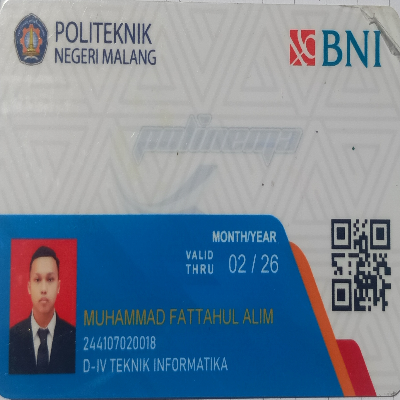

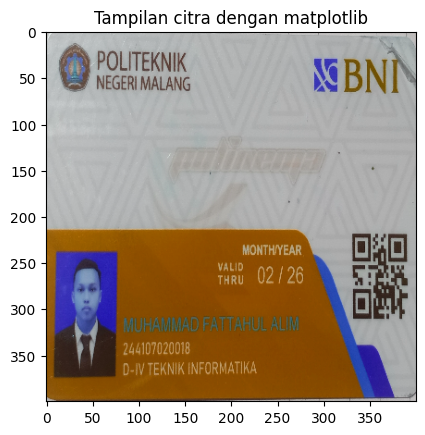

Nilai piksel dari pembacaan OpenCV     (BGR): [180 185 186]
Nilai piksel dari pembacaan Matplotlib (RGB): [180 185 186]


In [ ]:
#Keluran program pertanyaan praktikum 1

#Membaca resize citra sehingga ukuran sama
img_p1_resize = cv.resize(img, (400, 400))

#Menamplikan gambar
print("Tampilan citra dengan cv2_imshow:")
cv2_imshow(img_p1_resize)
plt.title("Tampilan citra dengan matplotlib")
plt.imshow(img_p1_resize)

#Koordinat pixel dan simpan warna koordinat pixel tersebut
y, x = 100, 100
pixel_cv = img_p1_resize[y, x]
pixel_plt = img_p1_resize[y, x]
plt.show()
#Menampilkan kedua nilai pixel
print(f"Nilai piksel dari pembacaan OpenCV     (BGR): {pixel_cv}")
print(f"Nilai piksel dari pembacaan Matplotlib (RGB): {pixel_plt}")

Kanvas 1 (dtype = int16)
Min: 0
Max: 0
Memory (nbytes): 1685400 bytes
Kanvas 2 (dtype = int32)
Min: 0
Max: 0
Memory (nbytes): 3370800 bytes


Text(0.5, 1.0, 'Kanvas Hitam (int32)')

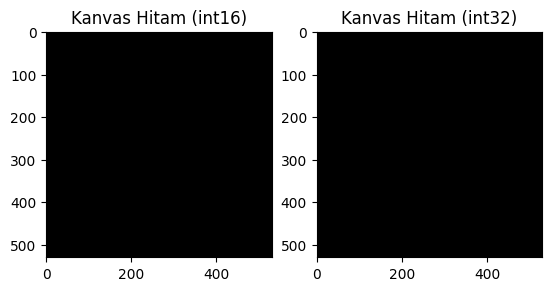

In [ ]:
#Keluran program pertanyaan praktikum 2


black_img_16 = np.zeros(shape=(530,530,3), dtype=np.int16)
black_img_32 = np.zeros(shape=(530,530,3), dtype=np.int32)

#Perbandingan nilai memori
print(f"Kanvas 1 (dtype = int16)")
print(f"Min: {black_img_16.min()}")
print(f"Max: {black_img_16.max()}")
print(f"Memory (nbytes): {black_img_16.nbytes} bytes")

print("==========================")
print(f"Kanvas 2 (dtype = int32)")
print(f"Min: {black_img_32.min()}")
print(f"Max: {black_img_32.max()}")
print(f"Memory (nbytes): {black_img_32.nbytes} bytes")

#Menampilkan kanvas hitam
plt.subplot(1, 2, 1)
plt.imshow(black_img_16)
plt.title('Kanvas Hitam (int16)')

plt.subplot(1, 2, 2)
plt.imshow(black_img_32)
plt.title('Kanvas Hitam (int32)')

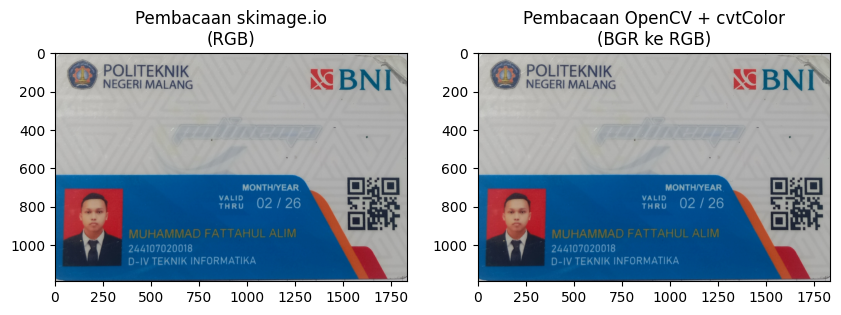

Nilai piksel skimage (RGB)           : [ 77  82 104]
Nilai piksel OpenCV konversi (RGB)   : [ 77  82 104]


In [ ]:
#Keluran program pertanyaan praktikum 4

#membaca citra dengan skimage dan opencv
img_skimage = io.imread('KTM_cahaya_matahari.jpg')
img_cv = cv.imread('KTM_cahaya_matahari.jpg')

#konversi citra dari opencv BGR -> RGB
img_cv_rgb = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_skimage)
plt.title('Pembacaan skimage.io\n(RGB)')

plt.subplot(1, 2, 2)
plt.imshow(img_cv_rgb)
plt.title('Pembacaan OpenCV + cvtColor\n(BGR ke RGB)')
plt.show()

# Bukti ekstraksi piksel
y, x = 100, 100
print(f"Nilai piksel skimage (RGB)           : {img_skimage[y, x]}")
print(f"Nilai piksel OpenCV konversi (RGB)   : {img_cv_rgb[y, x]}")

Shape citra: (1188, 1834, 3)


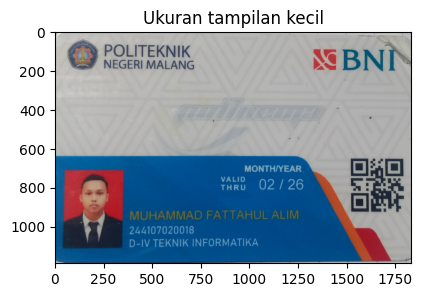

Shape setelah figsize kecil: (1188, 1834, 3)


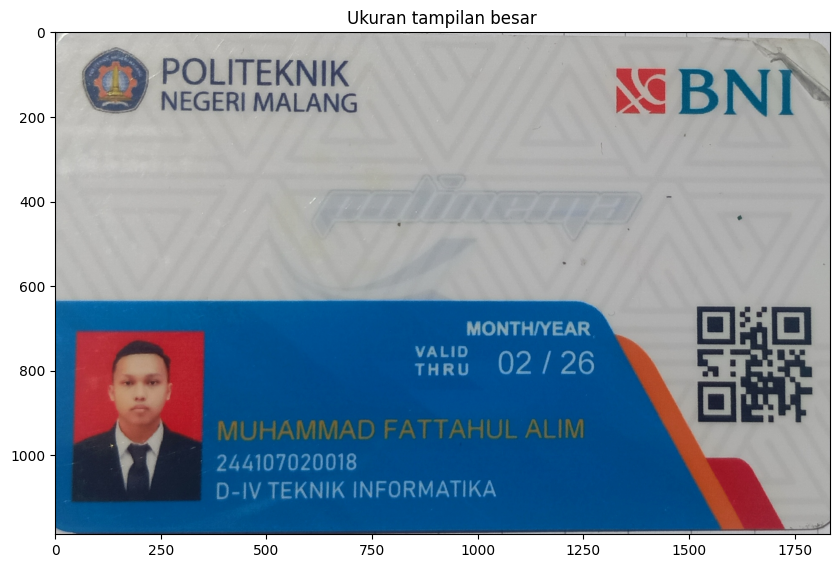

Shape setelah figsize besar: (1188, 1834, 3)


In [ ]:
#Keluaran program pertanyaan praktikum 5

#Menampilkan shape sebelum figsize
print("Shape citra:", img.shape)

# Menampilkan citra dengan ukuran figure kecil
plt.figure(figsize=(5, 3))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Ukuran tampilan kecil")
plt.show()

#shape citra setelah ditampilkan dengan figsize kecil
print("Shape setelah figsize kecil:", img.shape)

# Menampilkan citra dengan ukuran figure lebih besar
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Ukuran tampilan besar")
plt.show()

# Shape citra setelah ditampilkan dengan figsize besar
print("Shape setelah figsize besar:", img.shape)

#Tugas Praktikum penerapan

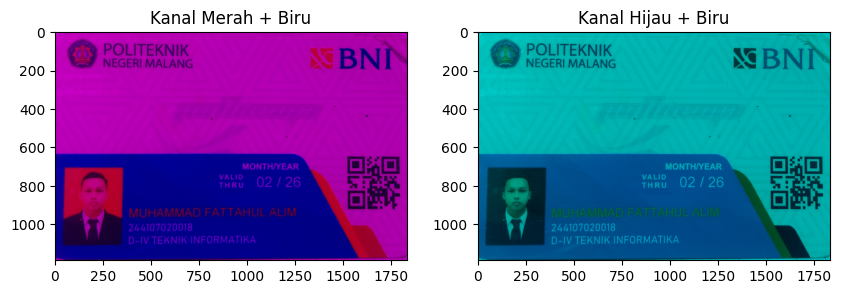

In [ ]:
# Tugas Praktikum 1

#citra kanal merah-biru
img_rb = img.copy()

#membuat kanal hijau 0
img_rb[:, :, 1] = 0

#citra kanal hijau-biru
img_gb = img.copy()

#membuat kanal merah 0
img_gb[:, :, 2] = 0

# Konversi BGR -> RGB untuk ditampilkan dengan matplotlib karena openCV memakai BGR
img_rb_rgb = cv.cvtColor(img_rb, cv.COLOR_BGR2RGB)
img_gb_rgb = cv.cvtColor(img_gb, cv.COLOR_BGR2RGB)

#menampilkan berdampingan
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_rb_rgb)
plt.title('Kanal Merah + Biru')

plt.subplot(1, 2, 2)
plt.imshow(img_gb_rgb)
plt.title('Kanal Hijau + Biru')

plt.show()


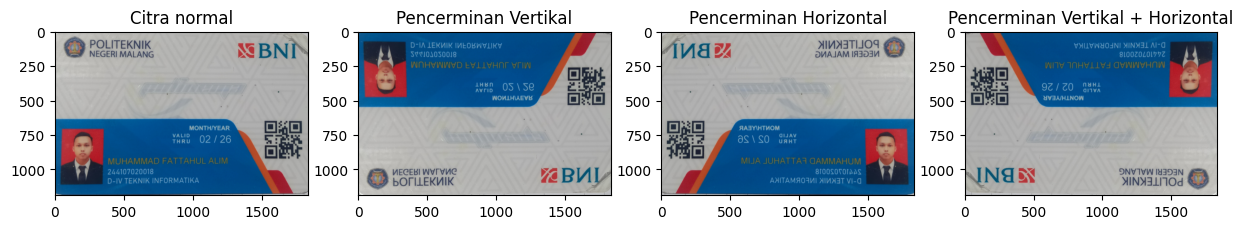

In [ ]:
# Tugas Praktikum 2

#menyiapkan citra
img_fl = img.copy()

#flip vertical
flip_vertical = cv.flip(img_fl, 0)

#flip horizontal
flip_horizontal = cv.flip(img_fl, 1)

#flip both
flip_both = cv.flip(img_fl, -1)

# Konversi BGR -> RGB untuk ditampilkan dengan matplotlib karena openCV memakai BGR
img_rgb = cv.cvtColor(img_fl, cv.COLOR_BGR2RGB)
flip_vertical_rgb = cv.cvtColor(flip_vertical, cv.COLOR_BGR2RGB)
flip_horizontal_rgb = cv.cvtColor(flip_horizontal, cv.COLOR_BGR2RGB)
flip_both_rgb = cv.cvtColor(flip_both, cv.COLOR_BGR2RGB)

# Menampilkan dalam satu figure
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Citra normal')

plt.subplot(1, 4, 2)
plt.imshow(flip_vertical_rgb)
plt.title('Pencerminan Vertikal')

plt.subplot(1, 4, 3)
plt.imshow(flip_horizontal_rgb)
plt.title('Pencerminan Horizontal')

plt.subplot(1, 4, 4)
plt.imshow(flip_both_rgb)
plt.title('Pencerminan Vertikal + Horizontal')

plt.show()

In [ ]:
# Tugas Praktikum 3

#upload gambar
uploaded2 = files.upload()

Saving myself.JPG to myself.JPG


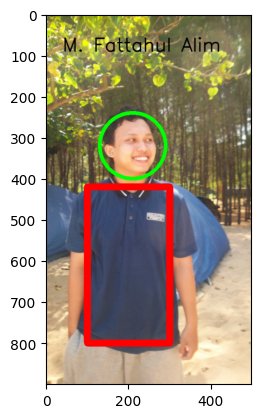

In [ ]:
#Membaca gambar
my_img = cv.imread('myself.JPG')

#resize
my_img = cv.resize(my_img, (500, 900))

#Konversi gambar
my_img_rgb = cv.cvtColor(my_img, cv.COLOR_BGR2RGB)

#Menggambar persegi dan lingkaran
cv.rectangle(my_img_rgb, pt1=(100,420), pt2=(300,800), color=(255,0,0), thickness=15)
cv.circle(my_img_rgb, center=(210, 320), radius=80, color=(0,255,0), thickness=8)
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(my_img_rgb, text='M. Fattahul Alim', org=(40, 90), fontFace=font, fontScale=1.5, color=(0,0,0), thickness=2, lineType=cv.LINE_AA)

#menampilkan gambar
plt.imshow(my_img_rgb)

# Tugas praktikum Analisa

Pertanyaan yang saya buat : berapa persen piksel pada kanal biru yang memiliki intensitas di atas 100 pada citra aktivitas saya?

In [ ]:
#Jawaban praktikum analisa

#Menyimpan gambar yang akan digunakan
prak_img = cv.imread('myself.JPG')

#Karena gambar berada di format BGR maka posisi biru ada di indeks '0'
#Proses mengambil kanal biru
blue_channel = prak_img[:, :, 0]

#Menghitung jumlah selururuh pixel
total_pixel = blue_channel.size

#menghitung jumlah piksel kanal biru yang intensitasnya > 100
blue_above_100 = np.sum(blue_channel > 100)

#Menghitung persentase
percentage = (blue_above_100 / total_pixel) * 100
print("Jumlah seluruh piksel :", total_pixel)
print("Piksel kanal biru > 100 :", blue_above_100)
print(f"Persentase kanal biru > 100 : {percentage:.2f}%")

Jumlah seluruh piksel : 10036224
Piksel kanal biru > 100 : 4382084
Persentase kanal biru > 100 : 43.66%


#Analisa
Citra di atas yang digunakan memiliki resolusi 2376 x 4224 px sehingga jumlah total pixel yang ada pada citra tersebut berjumlah 10036224 pixel. Berdasarkan program yang telah dibuat, sebanyak 4.382.084 piksel (43,66%) memiliki nilai intensitas kanal biru (B) di atas 100. Sementara itu, 5.654.140 piksel (56,34%) lainnya memiliki nilai intensitas kanal biru (B) kurang dari atau sama dengan 100. Perhitungan tersebut hanya menghitung nilai pada kanal biru, sedangkan nilai kanal merah (R) dan hijau (G) pada piksel tersebut tetap ada tetapi tidak ikut diperhitungkan.

# Tugas Praktikum Aplikasi

In [ ]:
# Upload 2 file untuk percobaan
uploaded3 = files.upload()
uploaded4 = files.upload()

#Ambil nama file upload
nama_file3 = list(uploaded3.keys())[0]
nama_file4 = list(uploaded4.keys())[0]

Saving hiking.jpg to hiking.jpg


Saving landscape.jpg to landscape.jpg


Text(0.5, 1.0, 'Foto dengan format landscape')

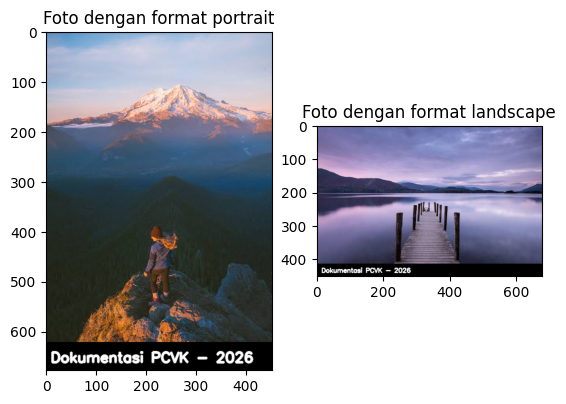

In [ ]:
#Tugas Praktikum 1
#baca citra yang diupload
img_portrait = cv.imread(nama_file3)
img_landscape = cv.imread(nama_file4)

#convert ke RGB
img_portrait = cv.cvtColor(img_portrait, cv.COLOR_BGR2RGB)
img_landscape = cv.cvtColor(img_landscape, cv.COLOR_BGR2RGB)

#membuat fungsi untuk menghitung dan menambahkan label identitas
def tambah_label(img, teks_label):
  h, w = img.shape[:2]
  img_hasil = img.copy()

  bar_height = h // 12
  font = cv.FONT_HERSHEY_SIMPLEX
  font_scale = bar_height / 60
  thickness = max(1, bar_height // 15)

  img_hasil[h-bar_height:h, :] = (0,0,0)

  posisi_teks = (int(w * 0.02), h - int(bar_height * 0.3))
  cv.putText(img_hasil, teks_label, posisi_teks, font, font_scale, (255, 255, 255), thickness, lineType=cv.LINE_AA)

  return img_hasil

hasil1= tambah_label(img_portrait, "Dokumentasi PCVK - 2026")
hasil2= tambah_label(img_landscape, "Dokumentasi PCVK - 2026")

plt.subplot(1,2,1)
plt.imshow(hasil1)
plt.title("Foto dengan format portrait")

plt.subplot(1,2,2)
plt.imshow(hasil2)
plt.title("Foto dengan format landscape")

Text(0.5, 1.0, 'Thumbnail dari foto landscape')

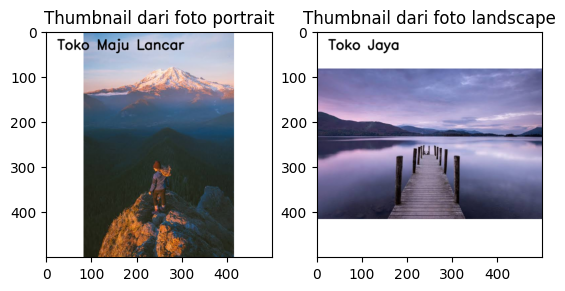

In [ ]:
#Tugas Praktikum 2
#baca citra yang diupload
img_portrait2 = cv.imread(nama_file3)
img_landscape2 = cv.imread(nama_file4)

#convert ke RGB
img_portrait2 = cv.cvtColor(img_portrait2, cv.COLOR_BGR2RGB)
img_landscape2 = cv.cvtColor(img_landscape2, cv.COLOR_BGR2RGB)

def buat_thumbnail(img, ukuran_target, nama_toko):
  h, w = img.shape[:2]
  img_sementara = img.copy()

  #hitung skala
  skala = ukuran_target / max(h, w)
  new_w = int(w * skala)
  new_h = int(h * skala)

  #resize sesuai skala
  resized = cv.resize(img_sementara, (new_w, new_h))

  #buat kanvas persegi warna putih
  canvas = np.full((ukuran_target, ukuran_target, 3), 255, dtype= np.uint8) #uint8 menyesuaikan dengan format gambar agar kanvas tidak mismatch type data

  #hitung offset agar citra tepat di tengah
  y_offset = (ukuran_target - new_h) // 2
  x_offset = (ukuran_target - new_w) // 2

  #masukkan citra ke kanvas
  canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

  #tambahkan logo nama toko, ukuran dan posisi dihitung dari ukuran_target
  font = cv.FONT_HERSHEY_SIMPLEX
  font_scale = ukuran_target / 500
  thickness = max(1, ukuran_target // 200)
  posisi_teks = (int(ukuran_target * 0.05), int(ukuran_target * 0.08))

  cv.putText(canvas, nama_toko, posisi_teks, font, font_scale, (0, 0, 0), thickness, lineType=cv.LINE_AA)

  return canvas

thumbnail1 = buat_thumbnail(img_portrait2, 500, "Toko Maju Lancar")
thumbnail2 = buat_thumbnail(img_landscape2, 500, "Toko Jaya")

#Tampilkan hasil

plt.subplot(1,2,1)
plt.imshow(thumbnail1)
plt.title("Thumbnail dari foto portrait")

plt.subplot(1,2,2)
plt.imshow(thumbnail2)
plt.title("Thumbnail dari foto landscape")